# Strut-and-Tie Modeling for Concrete Bridge Design

This notebook provides computational tools for strut-and-tie modeling (STM)
of reinforced concrete bridge components. It covers:

1. **AASHTO LRFD STM Provisions** (Section 5.8.2) -- node types, strut
   efficiency factors, tie design
2. **FHWA NHI-17-071 Design Procedure** -- 11-step pier cap design example
3. **Topology Optimization** -- ESO/SESO methods for automated STM generation
4. **Algorithmic STM** -- Ground structure method with linear programming

References:
- FHWA NHI-17-071, *Strut-and-Tie Modeling (STM) for Concrete Structures*
- AASHTO LRFD Bridge Design Specifications, 9th Ed., Section 5.8.2
- Breyer et al., *Design of Wood Structures* (for comparison)
- Cunningham, L., *Automatic Design of Concrete Structures Using STM*, Ph.D. Thesis, Univ. Glasgow, 2000
- Simonetti et al., *An Efficient Python Code for STM Topology Optimization Using SESO and ESO*, 2021
- UT Austin CTR Report 0-4371-S, *Example STM Designs*
- Sigmund, O., *99-Line Topology Optimization Code in MATLAB*, 2001

## Section 1 

Total number of supporting columns (piers) in a full pier cap. Can be  
symmetrical or asymmetrical. A check is provided if it's symmetrical. 

The spreadsheet is designed for a maximum of 8 columns for symmetrical  
piers and 4 columns for asymmetrical pier caps.

For symmetrical pier caps, the input and output of the analysis are limited  
up to the centerline. For asymmetrical, the full pier cap analysis is  
performed.

After providing the number of columns, the excel sheet generates a model  
for the user.

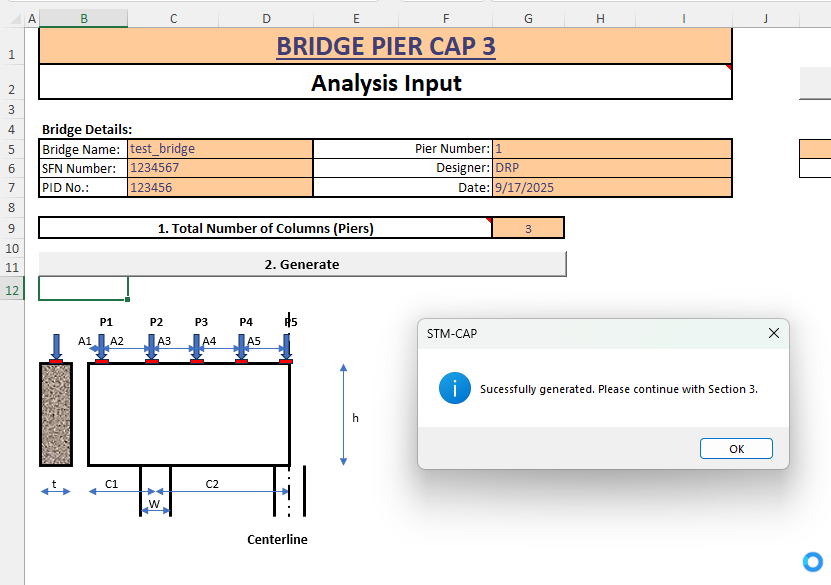

In [1]:
bridge_name = "test_bridge"
sfn = 1234567
pid = 123456
pier_number = 1
designer = 'DRP'
date = '9/17/2025'

total_columns = 3

## Section 2 - Diagram Generation

Outputs for values, this is kind of cool, but I'm not going to recreate it.  
the modern solution would probably be to do it in Rhino or another CADD  
application.

(actually after writing I realized they're probably just static files and  
not generative, there's only 7 cases)


2:

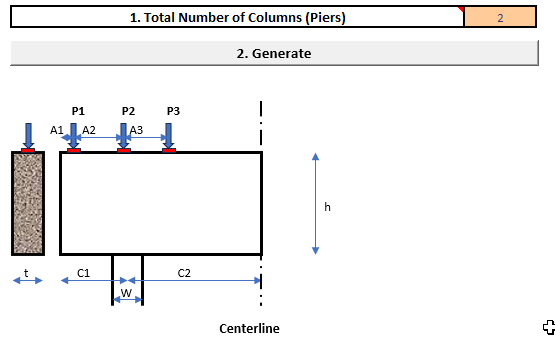

3:

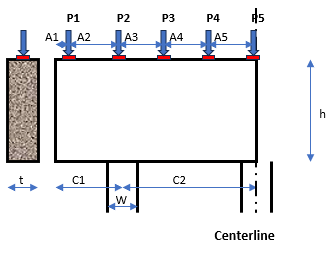

4:

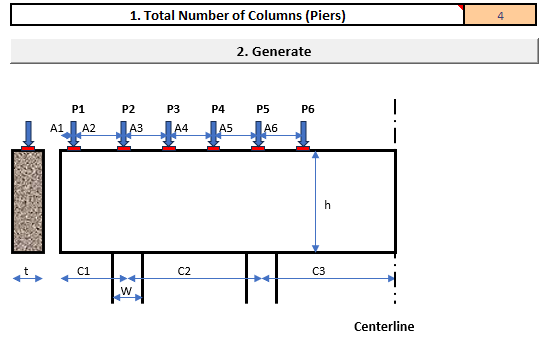

5:

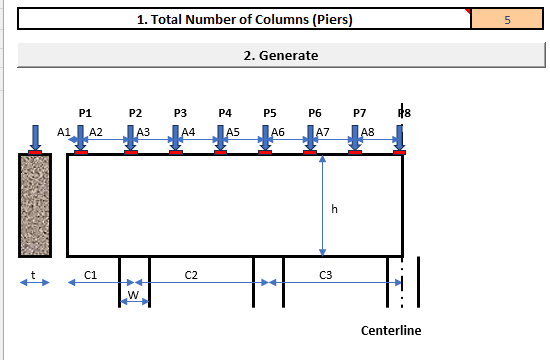

6:

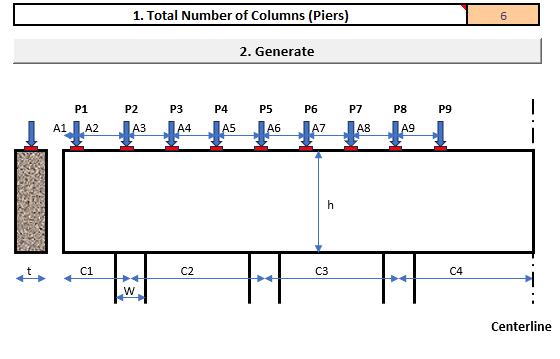

7:

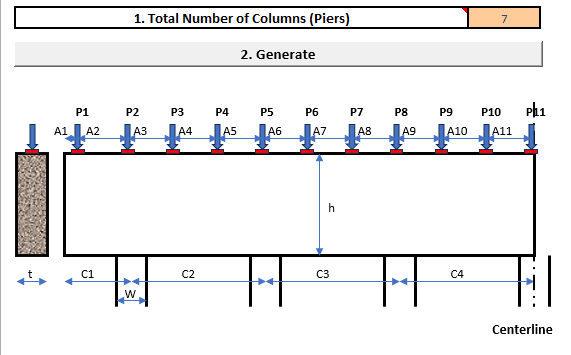

8:

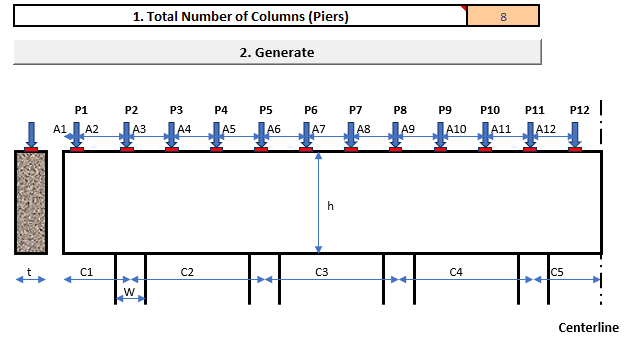

## Section 3 - Geometry Details

Depending on the number of columns the user has selected, the geometry  
inputs vary.

8 Columns:

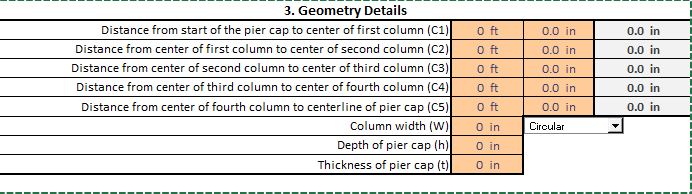

3 Columns (Example Problem):

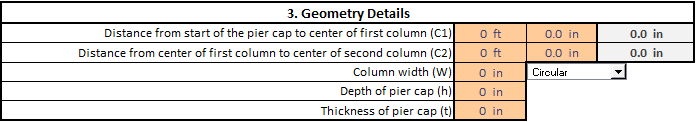

In [2]:
a_p_values_len = (total_columns * 3 + 1) // 2
c_values_len = (total_columns // 2) + 1

In [4]:
# Get Variable length inputs from the user, for the example use 1.5, 12.48
c_values = {}

for i in range(0, (total_columns // 2) + 1, 1):
    c_values[f"C{i+1}"] = input(f"Enter the value for length C{i+1}")

Enter the value for length C1 
Enter the value for length C2 


In [5]:
# These inputs are not variable, could probably benefit from assuming and overriding if needed
column_width = 3
cap_depth = 3
cap_thick = 3

## Section 4 - Factored Loads and their Position

# References

## FHWA Design Examples

[FHWA Design Examples](https://www.fhwa.dot.gov/bridge/concrete/nhi17071.pdf)

### Step 1 - Define Strut and Tie Model Input

### Step 2 - Determine the Locations of the B- and D-Regions

### Step 3 - Define Load Cases

### Step 4 - Analyze Structural Components

### Step 5 - Size Structural Components Using the Shear Serviceability Check

### Step 6 - Develop a Strut and Tie Model

### Step 7 - Proportion Ties

### Step 8 - Perform Nodal Strength Checks

### Step 9 - Proportion Crack Control Reinforcement

### Step 10 - Provide Necessary Anchorage for Ties

### Step 11 - Draw Reinfrocement Layout

## Automatic Design of Concrete Structures Using a Strut and Tie Approach

[Lee Cunningham, Ph.D.](https://theses.gla.ac.uk/1726/1/2000cunninghamphd.pdf)

### Chapter 1 - Intro

**Notation:**

$ A_s $ = Area of steel  
$ A_{sx} $ = Area of steel in the x-direction  
$ A_{sy} $ = Area of steel in the y-direction  
$ B $ = Shear Retention factor at cracking strain of concrete  
$ [B] $ = Strain matrix  
$ C_1,\ C_2 $ = Tension stiffening coefficients  
$ C $ = Strut  
$ [D] $ = Elasticity matrix  
$ [D'] $ = Instantaneous elasticity matrix  
$ [D_{cr}] $ = Rigidity inplane matrix for cracked concrete  
$ E $ = Young's Modulus  
$ E_c $ = Young's Modulus of concrete  
$ E_i $ = Instantaneous Young's Modulus of concrete  
$ E_s $ = Young's Modulus of steel  
$ f_c $ = Effective compressive strength of concrete  
$ f'_c $ = Cylinder compressive strength of concrete  
$ f_cc $ = Intermediate yield surface strength of concrete  
$ f_cd $ = Design compressive strength of concrete  
$ f_cu $ = Cube compressive strength of concrete  
$ f_t $ = Tensile strength of concrete  
$ f_y $ = Tensile strength of steel  
$ \{F\} $ = Nodal forces vector in Cartesian coords  
$ \{F'\} $ = Nodal forces vector in local coord system, (n,t)  
$ G $ = Shear modulus  
$ H $ = Strain hardening parameter for steel  
$ [K] $ = Stiffness matrix  
$ M $ = Bending moment  
$ M_1,\ M_2 $ = Principal moments  
$ M_d $ = Design Moment  
$ M_p $ = Plastic Moment  
$ M_x,\ M_y,\ M_{xy} $ = Applied moments at a point in Cartesian coords  
$ M_n,\ M_t,\ M_{nt} $ = Applied moments at a point in local coord system (n,t)  
$ M_x^*,\ M_y^* $ = Design moments in x and y directions  
$ M_u $ = Ultimate Moment  
$ n_x,\ n_y,\ n_z $ = Applied inplane forces in Cartesian coords  
$ N $ = Total number of nodal points  
$ N_i $ = Shape function associated with node I  
$ P $ = Applied Load  
$ P_{cr} $ = First cracking load  
$ P_d $ = Design load  
$ P_u $ = Ultimate load  
$ q $ = Intensity of uniformly distributed load  
$ rr $ = Rejection Ratio  
$ 1/R $ = Curvature  
$ 1/R_y $ = Curvature at yield  
$ \{R\} $ = Residual force vector  
$ T $ = Tie  
$ T_c $ = Concrete tie  
$ T_s $ = Steel tie  
$ [T] $ = Transformation matrix  
$ u,\ v,\ w $ = Displacements at a point in x, y, z coords  
$ u_0,\ v_0,\ w_0 $ = Displacements at a point in the reference plane of a plate  
$ x,\ y,\ z $ = Cartesian coord system  
$ z_i $ = Distance from the refrence plane to the center of the ith layer  

$ \alpha $ = Design compressive strength factor  
$ \beta $ = Shear retention factor  
$ \gamma $ = Material factor  
$ \gamma_{xz}, \gamma_{yz} $ = Shear strain components in cartesian coords  
$ \{\delta\} $ = Nodal displacement vector in cartesian coords  
$ \varepsilon_{cr} $ = Cracking strain of concrete  
$ \varepsilon_{O} $ = Strain at peak stress of concrete  
$ \varepsilon_x,\ \varepsilon_y,\ \gamma_{xy} $ = Strain components in cartesian coords.  
$ \varepsilon_x $ = Yield strain of steel  
$ \zeta $ = Variation of $\sigma_e^{VM}$ from $\sigma_{max}^{VM}$ in a structure  
$ \theta $ = Angle of the principal plane  
$ \theta_{cr} $ = Angle of crack with respect to x-axis  
$ \theta_x, \theta_y $ = Rotations about x and y axes respectively  
$ \theta_n, \theta_t $ = Rotations about n and t axes respectively  
$ v $ = Poisson's ratio  
$ \xi,\ \eta $ = Local, (natural) coord system  
$ \rho_x, \rho_y $ = Steel ratios in x and y directions  
$ \sigma $ = Stress at a point  
$ \{\sigma\} $ = Stress vector  
$ \sigma_1, \sigma_2 $ = Principal stresses  
$ \sigma_p $ = Peak stress  
$ \sigma_n $ = Normal stress  
$ \sigma_{oct} $ = Octahedral stress  
$ \sigma_x,\ \sigma_y,\ \sigma_{xy} $ = Stress components in cartesian coords  
$ \sigma_e^{VM} $ = Average von Mises stress in an element  
$ \sigma_{max}^{VM} $ = Maximum von Mises stress in an element  
$ \tau_{oct} $ = Octahedral shear stress  
$ \tau_{xy},\ \tau_{xz},\ \tau_{yz} $ = The shear stresses in xy, xz, yz planes respectively  
$ \phi $ = Reinforcement bar diameter  
$ \phi_x,\ \phi_y $ = Transverse shear rotations about xz and yz planes respectively  
$ \vartheta $ = Convergence Tolerance  
$ \omega $ = Degree of transverse reinforcement  

With Strut and tie modelling the load carrying mechanism of the structure  
is represented by approximating the compressive stress fields as struts and  
tensile stress fields as ties. The stress in the struts and ties should not  
exceed the allowable compressive strength of the concrete or yield strength  
of the steel respectively.

Two impartant issues need to be addressed in the design of structures by this method.  The first is visualizing an appropriate strut-tie model for a given structural system. 

### Chapter 2 - The Strut and Tie Method

### Chapter 3 - The Finite Element Method

### Chapter 4 - Model Visualisation and Direct Design

### Chapter 5 - Material Behaviour and Numerical Modelling

### Chapter 6 - Slab Design

### Chapter 7 - Experimental Program

### Chapter 8 - Strut & Tie Design

### Chapter 9 - Conclusions

### References

# An Efficient Python Code for Modelling Strut and Tie

[link](https://www.researchgate.net/profile/Helio-Simonetti-3/publication/356835814_An_efficient_Python_code_for_modelling_strut-and-tie_tridimensional_models_for_topological_optimization_using_SESO_and_ESO_methods/links/61af7850d3c8ae3fe3ee806b/An-efficient-Python-code-for-modelling-strut-and-tie-tridimensional-models-for-topological-optimization-using-SESO-and-ESO-methods.pdf)

Building on previous research in topographical optimization (see refs).

## 2. Problem Formulation

Primary formulas, (Direct quotes from 99 Line Matlab Topology Opitimization)

$$
\begin{align*}
\text{Minimize:} \quad W(u) \\
\text{Subject to:} \quad KU &= F \\
V(X) &= \sum_{i=1}^{NE} X_i V_i - \bar V \leq 0 \\
X &= \{x_1, x_2, x_3, \dots, x_n\}, \quad x_i \in \{0, 1\}
\end{align*} \tag{1}
$$

Considering the topology optimization problem as minimizing the deformation  
energy of a given structure considering the equilibrium, it follows that  
$W=2U$. The problem can then be defined as:

$$
\begin{align*}
\text{Minimize:} \quad U(X) &= \frac{1}{2}U^TKU = \sum^{NE}_1\frac{1}{2} \int_{Ve} \varepsilon_e^T E_e(x)\varepsilon_edV_e \\
\text{Subject to:} \quad KU &= F \\
V(X) &= \sum_{i=1}^{NE} X_i V_i - \bar V \leq 0 \\
X &= \{x_1, x_2, x_3, \dots, x_n\}, \quad x_i \in \{0, 1\}
\end{align*} \tag{2}
$$

Where:

$ E_e $ = The element's elasticity matrix  
$ \varepsilon_e $ = The element's strain vector  
$ V_e $ = The volume of an element  
$ NE $ = The number of finite elements of the mesh  
$ K $ = Stiffness matrix  
$ KU = F $ = Equilibrium Equation  
$ F $ = Vector of loads applied to the structure  
$ x_i $ = design variable of the ith element  
$ X $ = the vector of design variables  

### 2.1 ESO and SESO

Xie and Steven [4] develeoped a simple way to make changes in the topology  
of a structure through a heuristic of gradual and systemic removal of  
finite elements from the mesh corresponding to regions that did not  
effectively contribute to the good performance of the structure. This  
method was called ESO.

SESO is based on ESO philosophy and applies a weighting to the constitutive  
matrix so that the element that would be removed from ESO, is maintained  
and receives a relaxation, Simonetti [23]. This relaxation is processed  
through the application of a degredation in the value of its initial  
stiffness in such a way that it remains in the design domain and that,  
naturally, during the removal process, its influence can contribute and  
determine its permanence or definitive removal from the design domain.

In this article, the maximization of the structure stiffness, minimizing  
the strain energy, is evaluated. In this way, the strain energy of each  
element can be evaluatied according to the following inequality:

$$ U_e < RR_k * (U_i^{max}) \tag{3} $$

Where $ U_e $ is the strain energy of the element, $U_i^{max}$ is the maximum  
strain energy of the structure in the effective iteration k. $RR_k$ is the  
rejection ratio of the k-th equilibrium state which can be defined  
according to Equation (4) and $ER$ is the Evolutionary Ratio:

$$ RR_{k+1} = RR_k + ER \tag{4} $$

The SESO procedure can then be interpreted as follows:

$$
D(j) =
\begin{cases}
    D_0, & \text{if } j \in \Gamma_i \\
    D_0 \cdot \eta_j(\bar \Gamma), & \text{if } j \in \Gamma_{GS} \\
    0, & \text{if } j \in \Gamma_{LS}
\end{cases} \tag{5}
$$

Where:

$D(j)$ is the constitutive matrix of element $j$, $\Gamma = \Gamma_{LS} + \Gamma_{GS} $ is the  
domain of elements that meet eq. (5), $\Gamma_{LSi}$ is the domain of elements  
that must be effectively removed, $\Gamma_GSi$ is the domain of elements that  
are returned to the structure, $ 0 \leq \eta (\bar \Gamma) \leq 1 $ is a weighted function

### 2.2 Performance Index 

Liang [2] presents in his research on linear elastic structures an approach  
that defines an energy-based performance index with the following equation:

$$ PI = \frac{C_0V_0}{C_kV_k} \tag{6} $$

Where:

$ PI $ = Performance index of the structure,  
$ C_0 $ = Initial compliance,  
$ V_0 $ = Initial volume of the structure,  
$ C_k $ = Compliance in the k-th iteration  
$ eV_k $ = Volume in the k-th iteration.  

In [ ]:
import numpy as np
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.optimize import linprog
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
import warnings
warnings.filterwarnings('ignore')

# AASHTO LRFD STM Provisions (Section 5.8.2)

## Node Classifications

Nodes are classified by the types of members framing into them:

| Node Type | Description | Efficiency Factor $\nu$ | AASHTO Ref |
|-----------|-------------|------------------------|------------|
| **CCC** | All struts (compression only) | 0.85 | 5.8.2.5.3a |
| **CCT** | Two+ struts and one tie | 0.70 | 5.8.2.5.3a |
| **CTT** | One strut and two+ ties | 0.65 | 5.8.2.5.3a |

## Limiting Compressive Stress in Struts

$$f_{cu} = \frac{f'_c}{0.8 + 170\varepsilon_1} \leq 0.85 f'_c$$

where $\varepsilon_1 = \varepsilon_s + (\varepsilon_s + 0.002) \cot^2 \alpha_s$

- $\varepsilon_s$ = tensile strain in the tie direction
- $\alpha_s$ = angle between strut and tie

## Node Face Stress Limit

$$\phi f_n = \phi \cdot 0.85 \cdot \nu \cdot f'_c$$

where $\phi = 0.70$ (strut-and-tie model resistance factor per AASHTO 5.5.4.2)

## Tie Design

$$A_s = \frac{T_u}{\phi f_y}$$

where $T_u$ is the factored tie force and $f_y$ is the steel yield strength.

In [ ]:
# ================================================================
# AASHTO LRFD STM Design Functions
# ================================================================

@dataclass
class Material:
    """Concrete and steel material properties for STM design."""
    fc: float = 4.0       # f'c in ksi
    fy: float = 60.0      # Steel yield strength in ksi
    Es: float = 29000.0   # Steel modulus in ksi
    phi_stm: float = 0.70 # STM resistance factor (AASHTO 5.5.4.2)

    @property
    def Ec(self):
        """Concrete modulus per AASHTO 5.4.2.4 (ksi)."""
        return 33000 * 0.150**1.5 * self.fc**0.5  # wc=150 pcf

    @property
    def fr(self):
        """Modulus of rupture per AASHTO 5.4.2.6 (ksi)."""
        return 0.24 * self.fc**0.5


def node_efficiency_factor(node_type: str) -> float:
    """Node efficiency factor nu per AASHTO 5.8.2.5.3a.
    
    Args:
        node_type: "CCC", "CCT", or "CTT"
    Returns:
        float: efficiency factor nu
    """
    factors = {"CCC": 0.85, "CCT": 0.70, "CTT": 0.65}
    return factors.get(node_type.upper(), 0.65)


def node_capacity(fc: float, nu: float, phi: float = 0.70) -> float:
    """Limiting compressive stress at a node face (ksi).
    
    phi * fn = phi * 0.85 * nu * f'c
    
    Args:
        fc: Concrete compressive strength f'c (ksi)
        nu: Node efficiency factor
        phi: Resistance factor (default 0.70)
    Returns:
        float: Factored node capacity stress (ksi)
    """
    return phi * 0.85 * nu * fc


def strut_limiting_stress(fc: float, epsilon_s: float, alpha_s_deg: float) -> float:
    """Limiting compressive stress fcu in a strut per AASHTO 5.8.2.5.3a.
    
    fcu = f'c / (0.8 + 170*eps1) <= 0.85*f'c
    eps1 = eps_s + (eps_s + 0.002) * cot^2(alpha_s)
    
    Args:
        fc: f'c (ksi)
        epsilon_s: tensile strain in tie crossing the strut
        alpha_s_deg: angle between strut and tie (degrees)
    Returns:
        float: fcu (ksi)
    """
    alpha_rad = np.radians(alpha_s_deg)
    if alpha_rad == 0:
        alpha_rad = 0.001
    eps1 = epsilon_s + (epsilon_s + 0.002) * (1.0 / np.tan(alpha_rad))**2
    fcu = fc / (0.8 + 170 * eps1)
    return min(fcu, 0.85 * fc)


def required_tie_steel(Tu: float, fy: float = 60.0, phi: float = 0.70) -> float:
    """Required steel area for a tie per AASHTO 5.8.2.4.1.
    
    As = Tu / (phi * fy)
    
    Args:
        Tu: Factored tie force (kips)
        fy: Steel yield strength (ksi)
        phi: Resistance factor
    Returns:
        float: Required As (in^2)
    """
    return Tu / (phi * fy)


def crack_control_reinforcement(bw: float, s: float, fy: float = 60.0) -> float:
    """Minimum crack control reinforcement per AASHTO 5.8.2.6.
    
    Av/s >= 0.003 * bw (in each direction)
    
    Args:
        bw: Member width (in)
        s: Bar spacing (in)
        fy: Steel yield strength (ksi)
    Returns:
        float: Required Av per spacing s (in^2)
    """
    return 0.003 * bw * s


# Demonstrate the provisions
mat = Material(fc=4.0, fy=60.0)
print("AASHTO LRFD STM Design Values")
print(f"  f'c = {mat.fc} ksi, fy = {mat.fy} ksi")
print(f"  Ec = {mat.Ec:.0f} ksi, fr = {mat.fr:.3f} ksi")
print(f"  phi_stm = {mat.phi_stm}")

print("\nNode Capacities (phi * fn):")
for ntype in ["CCC", "CCT", "CTT"]:
    nu = node_efficiency_factor(ntype)
    cap = node_capacity(mat.fc, nu)
    print(f"  {ntype}: nu = {nu:.2f}, phi*fn = {cap:.3f} ksi")

print(f"\nStrut limiting stress (eps_s=0.002, alpha=30 deg):")
fcu = strut_limiting_stress(4.0, 0.002, 30.0)
print(f"  fcu = {fcu:.3f} ksi")

print(f"\nTie steel for Tu = 200 kips:")
As = required_tie_steel(200.0, 60.0)
print(f"  As_req = {As:.2f} in^2")

print(f"\nCrack control: bw=36 in, s=12 in:")
Av = crack_control_reinforcement(36.0, 12.0)
print(f"  Av_req = {Av:.3f} in^2")

# STM Truss Solver

A strut-and-tie model is fundamentally a truss. The solver below takes
node coordinates, element connectivity, boundary conditions, and applied
loads, then solves for member forces using the direct stiffness method.
This enables automated STM analysis for any geometry.

In [ ]:
# ================================================================
# 2D Truss Solver for Strut-and-Tie Models
# ================================================================

@dataclass
class STMNode:
    """A node in the strut-and-tie model."""
    x: float  # x-coordinate (in.)
    y: float  # y-coordinate (in.)
    fx: float = 0.0   # Applied force in x (kips)
    fy: float = 0.0   # Applied force in y (kips)
    fix_x: bool = False  # Restrained in x?
    fix_y: bool = False  # Restrained in y?
    node_type: str = ""  # "CCC", "CCT", "CTT", or ""

@dataclass
class STMElement:
    """An element (strut or tie) in the STM."""
    node_i: int  # Start node index
    node_j: int  # End node index
    member_type: str = "strut"  # "strut" or "tie"
    area: float = 1.0  # Cross-sectional area (in^2), used for stiffness


class STMTrussSolver:
    """2D truss solver for strut-and-tie models.
    
    Uses the direct stiffness method to solve for member forces.
    Struts carry compression, ties carry tension.
    
    Example:
        solver = STMTrussSolver()
        solver.add_node(0, 0, fix_x=True, fix_y=True)  # Support
        solver.add_node(48, 0, fix_y=True)               # Support
        solver.add_node(24, 36, fy=-100)                  # Load point
        solver.add_element(0, 2, "strut")
        solver.add_element(1, 2, "strut")
        solver.add_element(0, 1, "tie")
        solver.solve()
    """
    
    def __init__(self, E=3600.0):
        """Args: E = modulus of elasticity (ksi), default for 4 ksi concrete."""
        self.nodes: List[STMNode] = []
        self.elements: List[STMElement] = []
        self.E = E
        self.forces = None
        self.displacements = None
        self.reactions = None
    
    def add_node(self, x, y, fx=0, fy=0, fix_x=False, fix_y=False, node_type=""):
        self.nodes.append(STMNode(x, y, fx, fy, fix_x, fix_y, node_type))
        return len(self.nodes) - 1
    
    def add_element(self, ni, nj, member_type="strut", area=1.0):
        self.elements.append(STMElement(ni, nj, member_type, area))
        return len(self.elements) - 1
    
    def _element_length(self, elem):
        ni, nj = self.nodes[elem.node_i], self.nodes[elem.node_j]
        return np.sqrt((nj.x - ni.x)**2 + (nj.y - ni.y)**2)
    
    def _element_angle(self, elem):
        ni, nj = self.nodes[elem.node_i], self.nodes[elem.node_j]
        return np.arctan2(nj.y - ni.y, nj.x - ni.x)
    
    def solve(self):
        """Solve the truss system for member forces and reactions."""
        n_nodes = len(self.nodes)
        n_dof = 2 * n_nodes
        
        # Global stiffness matrix
        K = np.zeros((n_dof, n_dof))
        
        for elem in self.elements:
            L = self._element_length(elem)
            theta = self._element_angle(elem)
            c, s = np.cos(theta), np.sin(theta)
            
            # Element stiffness in global coordinates
            k_local = (self.E * elem.area / L) * np.array([
                [ c*c,  c*s, -c*c, -c*s],
                [ c*s,  s*s, -c*s, -s*s],
                [-c*c, -c*s,  c*c,  c*s],
                [-c*s, -s*s,  c*s,  s*s],
            ])
            
            # DOF indices
            dofs = [2*elem.node_i, 2*elem.node_i+1,
                    2*elem.node_j, 2*elem.node_j+1]
            for i_local in range(4):
                for j_local in range(4):
                    K[dofs[i_local], dofs[j_local]] += k_local[i_local, j_local]
        
        # Force vector
        F = np.zeros(n_dof)
        for i, node in enumerate(self.nodes):
            F[2*i] = node.fx
            F[2*i+1] = node.fy
        
        # Apply boundary conditions (penalty method)
        penalty = 1e12
        for i, node in enumerate(self.nodes):
            if node.fix_x:
                K[2*i, 2*i] += penalty
            if node.fix_y:
                K[2*i+1, 2*i+1] += penalty
        
        # Solve
        U = np.linalg.solve(K, F)
        self.displacements = U
        
        # Compute member forces
        self.forces = []
        for elem in self.elements:
            L = self._element_length(elem)
            theta = self._element_angle(elem)
            c, s = np.cos(theta), np.sin(theta)
            
            ui = U[2*elem.node_i:2*elem.node_i+2]
            uj = U[2*elem.node_j:2*elem.node_j+2]
            
            # Axial deformation in element direction
            delta = (uj[0] - ui[0]) * c + (uj[1] - ui[1]) * s
            force = self.E * elem.area * delta / L
            self.forces.append(force)
        
        # Compute reactions
        self.reactions = {}
        for i, node in enumerate(self.nodes):
            if node.fix_x or node.fix_y:
                rx = penalty * (0 - U[2*i]) if node.fix_x else 0
                ry = penalty * (0 - U[2*i+1]) if node.fix_y else 0
                self.reactions[i] = (rx, ry)
        
        return self.forces
    
    def print_results(self):
        """Print member forces and reactions."""
        print("Member Forces:")
        print(f"  {'Elem':>4s}  {'Type':>5s}  {'Node i':>6s}  {'Node j':>6s}  "
              f"{'Length':>8s}  {'Force':>10s}  {'Status':>8s}")
        print("  " + "-" * 60)
        for idx, (elem, force) in enumerate(zip(self.elements, self.forces)):
            L = self._element_length(elem)
            status = "C (strut)" if force < -0.01 else "T (tie)" if force > 0.01 else "zero"
            print(f"  {idx:4d}  {elem.member_type:>5s}  {elem.node_i:6d}  "
                  f"{elem.node_j:6d}  {L:8.1f}  {force:10.2f}  {status:>8s}")
        
        print("\nReactions:")
        for node_id, (rx, ry) in self.reactions.items():
            print(f"  Node {node_id}: Rx = {rx:.2f} k, Ry = {ry:.2f} k")
    
    def plot(self, scale=50, figsize=(14, 8)):
        """Visualize the STM with color-coded members.
        
        Blue = ties (tension), Red = struts (compression), 
        line width proportional to force magnitude.
        """
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        
        if self.forces is None:
            self.solve()
        
        max_force = max(abs(f) for f in self.forces) if self.forces else 1.0
        
        for idx, (elem, force) in enumerate(zip(self.elements, self.forces)):
            ni, nj = self.nodes[elem.node_i], self.nodes[elem.node_j]
            color = 'blue' if force > 0.01 else 'red' if force < -0.01 else 'gray'
            lw = max(1, 5 * abs(force) / max_force)
            ax.plot([ni.x, nj.x], [ni.y, nj.y], color=color, linewidth=lw, zorder=1)
            
            # Label with force
            mx, my = (ni.x + nj.x) / 2, (ni.y + nj.y) / 2
            ax.annotate(f"{abs(force):.1f}k", (mx, my), fontsize=7,
                       ha='center', va='bottom', color=color,
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                                alpha=0.8, edgecolor='none'))
        
        # Draw nodes
        for i, node in enumerate(self.nodes):
            if node.fix_x or node.fix_y:
                marker = '^' if node.fix_y else '>'
                ax.plot(node.x, node.y, marker, color='green', markersize=12, zorder=3)
            else:
                ax.plot(node.x, node.y, 'ko', markersize=6, zorder=3)
            
            # Draw applied loads
            if abs(node.fy) > 0.01:
                ax.annotate('', xy=(node.x, node.y),
                           xytext=(node.x, node.y - np.sign(node.fy) * scale/2),
                           arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))
                ax.text(node.x, node.y - np.sign(node.fy) * scale/2.5,
                       f"{abs(node.fy):.0f}k", ha='center', va='top', fontsize=8,
                       color='darkgreen')
            
            ax.text(node.x, node.y + 2, f"N{i}", ha='center', va='bottom', fontsize=7)
        
        ax.set_aspect('equal')
        ax.set_xlabel('x (in.)')
        ax.set_ylabel('y (in.)')
        ax.set_title('Strut-and-Tie Model\nRed = Strut (C), Blue = Tie (T)')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        return fig, ax


print("STM Truss Solver loaded.")

# FHWA Pier Cap Design Example (NHI-17-071)

Three-column pier cap with two point loads from superstructure bearings.
This follows the 11-step FHWA procedure using the STM truss solver.

**Geometry:**
- Cap width = 36 in., cap depth = 48 in.
- 3 columns at 12 ft spacing
- 2 bearing loads at 6 ft from columns
- f'c = 4 ksi, fy = 60 ksi

In [ ]:
# ================================================================
# FHWA Pier Cap STM Example
# ================================================================

# Step 1: Define geometry and materials
mat = Material(fc=4.0, fy=60.0)
cap_width = 36    # in
cap_depth = 48    # in
col_spacing = 144  # 12 ft = 144 in
bearing_offset = 72  # 6 ft from column centerlines

# Cover and tie centroid offset
cover = 3.0  # in
tie_offset = cover + 0.5  # approximate centroid of bottom reinforcement

# Step 2: B- and D-regions
# The entire pier cap is a D-region because the depth (48 in) is comparable
# to the span between loads. a/d < 2 for all load paths.
print("Step 2: D-Region identification")
print(f"  Cap depth = {cap_depth} in.")
print(f"  Clear span between columns = {col_spacing} in.")
print(f"  a/d ratio = {col_spacing / cap_depth:.1f} -- entire cap is D-region")

# Step 3: Load cases (Strength I)
# Example: two bearing loads from superstructure
P_bearing = 400  # kips per bearing (factored Strength I)
print(f"\nStep 3: Factored load = {P_bearing} kips per bearing")

# Step 4-5: Analyze and size (use solver)
# Step 6: Develop the strut-and-tie model
#
# Nodes:
#   0,1,2 = column tops (bottom chord - CCC or CCT nodes)
#   3,4   = bearing load points (top chord)
#   5,6   = intermediate top chord nodes above columns 0 and 2
#
# The STM uses diagonal struts from column tops to bearing points
# and horizontal ties along the bottom

stm = STMTrussSolver(E=mat.Ec)

# Bottom chord nodes (at column tops, at centroid of tie reinforcement)
y_bot = tie_offset  # bottom tie level
y_top = cap_depth - cover  # top strut level

# Column positions (x = 0, 144, 288 in.)
n0 = stm.add_node(0, y_bot, fix_x=True, fix_y=True, node_type="CCT")
n1 = stm.add_node(col_spacing, y_bot, fix_x=False, fix_y=True, node_type="CCC")
n2 = stm.add_node(2 * col_spacing, y_bot, fix_y=True, node_type="CCT")

# Top chord nodes (bearing locations)
# Bearing 1: midway between col 0 and col 1
x_brg1 = col_spacing / 2  # 72 in
# Bearing 2: midway between col 1 and col 2
x_brg2 = col_spacing + col_spacing / 2  # 216 in

n3 = stm.add_node(x_brg1, y_top, fy=-P_bearing, node_type="CCT")
n4 = stm.add_node(x_brg2, y_top, fy=-P_bearing, node_type="CCT")

# Top chord nodes above columns (for horizontal strut)
n5 = stm.add_node(col_spacing, y_top, node_type="CCC")

# Elements:
# Diagonal struts
stm.add_element(n0, n3, "strut", area=cap_width * 10)   # Left diagonal
stm.add_element(n1, n3, "strut", area=cap_width * 10)   # Left inner diagonal
stm.add_element(n1, n4, "strut", area=cap_width * 10)   # Right inner diagonal
stm.add_element(n2, n4, "strut", area=cap_width * 10)   # Right diagonal

# Horizontal top chord (compression strut between bearings through col 1)
stm.add_element(n3, n5, "strut", area=cap_width * 8)
stm.add_element(n5, n4, "strut", area=cap_width * 8)

# Horizontal bottom tie
stm.add_element(n0, n1, "tie", area=cap_width * 6)
stm.add_element(n1, n2, "tie", area=cap_width * 6)

# Solve
forces = stm.solve()
stm.print_results()

print(f"\nStep 6: STM model solved -- {len(stm.elements)} members, {len(stm.nodes)} nodes")

In [ ]:
# Visualize the pier cap STM
fig, ax = stm.plot(scale=30, figsize=(16, 6))

# Draw the pier cap outline
cap_rect = patches.Rectangle((- 12, 0), 2 * col_spacing + 24, cap_depth,
                               linewidth=2, edgecolor='black', facecolor='lightyellow',
                               alpha=0.3, zorder=0)
ax.add_patch(cap_rect)

# Draw column outlines
col_w = 36
for cx in [0, col_spacing, 2 * col_spacing]:
    col_rect = patches.Rectangle((cx - col_w/2, -48), col_w, 48,
                                   linewidth=1.5, edgecolor='gray', facecolor='lightgray',
                                   alpha=0.3, zorder=0)
    ax.add_patch(col_rect)

ax.set_xlim(-50, 2 * col_spacing + 50)
ax.set_ylim(-60, cap_depth + 30)
ax.set_title("Pier Cap Strut-and-Tie Model (FHWA NHI-17-071)")
plt.show()

In [ ]:
# ================================================================
# Steps 7-11: Design the members
# ================================================================

# Step 7: Proportion ties
# Identify tie forces (positive = tension)
tie_forces = [(i, f) for i, (e, f) in enumerate(zip(stm.elements, stm.forces))
              if e.member_type == "tie" and f > 0.01]

print("Step 7: Tie Design")
print(f"  phi = {mat.phi_stm}, fy = {mat.fy} ksi")
for idx, force in tie_forces:
    As_req = required_tie_steel(force, mat.fy, mat.phi_stm)
    # Select bars: try #8 bars (Ab = 0.79 in^2)
    Ab = 0.79  # #8 bar
    n_bars = int(np.ceil(As_req / Ab))
    As_prov = n_bars * Ab
    print(f"  Element {idx}: Tu = {force:.1f} k -> As_req = {As_req:.2f} in^2 "
          f"-> Use {n_bars}-#8 (As = {As_prov:.2f} in^2)")

# Step 8: Nodal strength checks
print("\nStep 8: Nodal Strength Checks")
for i, node in enumerate(stm.nodes):
    if node.node_type:
        nu = node_efficiency_factor(node.node_type)
        fn = node_capacity(mat.fc, nu, mat.phi_stm)
        # Maximum applied stress at node (simplified: use reaction or load)
        if i in stm.reactions:
            P_node = max(abs(stm.reactions[i][0]), abs(stm.reactions[i][1]))
        elif abs(node.fy) > 0:
            P_node = abs(node.fy)
        else:
            P_node = 0
        # Bearing area (simplified)
        A_bearing = cap_width * 12  # 36" x 12" bearing plate
        f_applied = P_node / A_bearing if A_bearing > 0 else 0
        ratio = f_applied / fn if fn > 0 else 0
        status = "OK" if ratio <= 1.0 else "NG"
        print(f"  Node {i} ({node.node_type}): fn = {fn:.3f} ksi, "
              f"f_applied = {f_applied:.3f} ksi, D/C = {ratio:.3f} [{status}]")

# Step 9: Crack control reinforcement
print("\nStep 9: Crack Control Reinforcement")
s_crack = 12  # 12 in spacing
Av_req = crack_control_reinforcement(cap_width, s_crack)
Ab_4 = 0.20  # #4 bar
n_legs = int(np.ceil(Av_req / Ab_4))
print(f"  Av_req = 0.003 * bw * s = 0.003 * {cap_width} * {s_crack} = {Av_req:.3f} in^2")
print(f"  Use {n_legs}-leg #4 stirrups @ {s_crack} in. o.c. each way")
print(f"  Av_prov = {n_legs * Ab_4:.2f} in^2 >= {Av_req:.3f} in^2 OK")

# Step 10: Anchorage
print("\nStep 10: Anchorage")
# Development length for #8 bar per AASHTO 5.10.8.2.1a
ld = 1.25 * Ab * mat.fy / (mat.fc**0.5)  # simplified
print(f"  Development length for #8: ld = {ld:.1f} in.")
print(f"  Available beyond node face: check per detailing")

# Step 11: Summary
print("\nStep 11: Design Summary")
print(f"  Pier cap: {cap_width}\" x {cap_depth}\" x {2*col_spacing + 24}\"")
print(f"  f'c = {mat.fc} ksi, fy = {mat.fy} ksi")
print(f"  Bottom tie reinforcement: see Step 7 above")
print(f"  Crack control: #4 @ {s_crack}\" each way")
print(f"  All nodal checks: see Step 8 above")

# Topology Optimization for Automated STM Generation

Topology optimization finds the optimal material distribution within a
design domain to minimize strain energy (maximize stiffness) subject to
a volume constraint. The resulting material layout reveals the natural
load paths -- struts and ties.

## Methods Implemented

### 1. SIMP (Solid Isotropic Material with Penalization)
The classic method from Sigmund's 99-line code. Each element has a
density variable $x_e \in [0, 1]$ that penalizes intermediate densities:

$$E_e(x_e) = x_{min} + x_e^p (E_0 - x_{min})$$

Optimality criteria update:

$$x_e^{new} = \begin{cases}
\max(0, x_e - m) & \text{if } x_e B_e^\eta \leq \max(0, x_e - m) \\
x_e B_e^\eta & \text{if } \max(0, x_e - m) < x_e B_e^\eta < \min(1, x_e + m) \\
\min(1, x_e + m) & \text{if } x_e B_e^\eta \geq \min(1, x_e + m)
\end{cases}$$

### 2. ESO/SESO (Evolutionary / Smooth Evolutionary Structural Optimization)
From Simonetti et al. -- elements with low strain energy relative to the
maximum are progressively removed (ESO) or softened (SESO):

$$U_e < RR_k \cdot U_{max} \implies \text{remove or soften element}$$

### 3. Ground Structure Method
Creates a dense truss of all possible member connections, then uses
linear programming to find the minimum-weight topology that satisfies
equilibrium and stress constraints.

In [ ]:
# ================================================================
# SIMP Topology Optimization (based on Sigmund's 99-line code)
# Adapted from MATLAB to Python for STM generation
# ================================================================

def topology_optimization_simp(nelx, nely, volfrac, penal, rmin,
                                loads, supports, max_iter=100):
    """2D topology optimization using SIMP method.
    
    Minimizes compliance (strain energy) subject to volume constraint.
    The resulting density field reveals strut-and-tie load paths.
    
    Args:
        nelx: Number of elements in x direction
        nely: Number of elements in y direction
        volfrac: Volume fraction constraint (0 to 1)
        penal: Penalization power (typically 3)
        rmin: Filter radius (in elements)
        loads: dict of {(node_x, node_y): (fx, fy)} -- applied forces
        supports: dict of {(node_x, node_y): (fix_x, fix_y)} -- BCs
        max_iter: Maximum iterations
    
    Returns:
        x: Optimized density array (nelx x nely)
        history: list of compliance values per iteration
    """
    # Element stiffness matrix for unit square element
    def element_stiffness():
        E0 = 1.0
        nu = 0.3
        k = np.array([
            1/2 - nu/6, 1/8 + nu/8, -1/4 - nu/12, -1/8 + 3*nu/8,
            -1/4 + nu/12, -1/8 - nu/8, nu/6, 1/8 - 3*nu/8
        ])
        KE = E0 / (1 - nu**2) * np.array([
            [k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
            [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
            [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
            [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
            [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
            [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
            [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
            [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]],
        ])
        return KE
    
    KE = element_stiffness()
    
    n_dof = 2 * (nelx + 1) * (nely + 1)
    
    # Initialize densities
    x = np.full((nely, nelx), volfrac)
    xold = x.copy()
    xPhys = x.copy()
    
    # Prepare filter
    H = np.zeros((nelx * nely, nelx * nely))
    for i1 in range(nelx):
        for j1 in range(nely):
            e1 = i1 * nely + j1
            for i2 in range(max(i1 - int(np.ceil(rmin)) + 1, 0),
                           min(i1 + int(np.ceil(rmin)), nelx)):
                for j2 in range(max(j1 - int(np.ceil(rmin)) + 1, 0),
                               min(j1 + int(np.ceil(rmin)), nely)):
                    e2 = i2 * nely + j2
                    dist = np.sqrt((i1 - i2)**2 + (j1 - j2)**2)
                    H[e1, e2] = max(0, rmin - dist)
    Hs = H.sum(axis=1)
    
    # DOF assembly
    def get_edof(elx, ely):
        n1 = (nely + 1) * elx + ely
        n2 = (nely + 1) * (elx + 1) + ely
        return np.array([
            2*n1, 2*n1+1, 2*n2, 2*n2+1,
            2*n2+2, 2*n2+3, 2*n1+2, 2*n1+3
        ])
    
    # Setup loads and BCs
    F = np.zeros(n_dof)
    for (nx, ny), (fx, fy) in loads.items():
        node_id = nx * (nely + 1) + ny
        F[2 * node_id] = fx
        F[2 * node_id + 1] = fy
    
    fixed_dofs = set()
    for (nx, ny), (fx_bc, fy_bc) in supports.items():
        node_id = nx * (nely + 1) + ny
        if fx_bc:
            fixed_dofs.add(2 * node_id)
        if fy_bc:
            fixed_dofs.add(2 * node_id + 1)
    
    all_dofs = set(range(n_dof))
    free_dofs = sorted(all_dofs - fixed_dofs)
    free_dofs = np.array(free_dofs)
    
    Emin = 1e-9
    E0_val = 1.0
    
    history = []
    
    for iteration in range(max_iter):
        # Assemble global stiffness
        K = lil_matrix((n_dof, n_dof))
        for elx in range(nelx):
            for ely in range(nely):
                edof = get_edof(elx, ely)
                Ee = Emin + xPhys[ely, elx]**penal * (E0_val - Emin)
                Ke = Ee * KE
                for ii in range(8):
                    for jj in range(8):
                        K[edof[ii], edof[jj]] += Ke[ii, jj]
        
        K = csr_matrix(K)
        
        # Solve
        U = np.zeros(n_dof)
        U[free_dofs] = spsolve(K[free_dofs][:, free_dofs], F[free_dofs])
        
        # Compliance and sensitivity
        compliance = 0.0
        dc = np.zeros((nely, nelx))
        for elx in range(nelx):
            for ely in range(nely):
                edof = get_edof(elx, ely)
                Ue = U[edof]
                ce = Ue @ KE @ Ue
                compliance += (Emin + xPhys[ely, elx]**penal * (E0_val - Emin)) * ce
                dc[ely, elx] = -penal * xPhys[ely, elx]**(penal - 1) * (E0_val - Emin) * ce
        
        history.append(compliance)
        
        # Apply filter
        dc_flat = dc.flatten('F')
        dc_filtered = (H @ (xPhys.flatten('F') * dc_flat)) / Hs / np.maximum(xPhys.flatten('F'), 1e-3)
        dc = dc_filtered.reshape((nely, nelx), order='F')
        
        # Optimality criteria update
        l1, l2 = 0, 1e9
        move = 0.2
        while (l2 - l1) / (l1 + l2) > 1e-3:
            lmid = 0.5 * (l2 + l1)
            xnew = np.maximum(0.001, np.maximum(x - move,
                    np.minimum(1.0, np.minimum(x + move,
                    x * np.sqrt(-dc / lmid)))))
            
            # Apply filter to physical densities
            xPhys_flat = (H @ xnew.flatten('F')) / Hs
            xPhys = xPhys_flat.reshape((nely, nelx), order='F')
            
            if xPhys.sum() > volfrac * nelx * nely:
                l1 = lmid
            else:
                l2 = lmid
        
        change = np.max(np.abs(xnew - x))
        x = xnew.copy()
        
        if iteration % 10 == 0 or change < 0.01:
            print(f"  Iter {iteration:3d}: compliance = {compliance:.4f}, "
                  f"vol = {xPhys.mean():.4f}, change = {change:.4f}")
        
        if change < 0.01 and iteration > 10:
            print(f"  Converged at iteration {iteration}")
            break
    
    return xPhys, history


print("SIMP topology optimizer loaded.")

## Example 1: Deep Beam Under Point Load

A simply supported deep beam with a concentrated load at midspan.
The topology optimization reveals the classic bottle-shaped strut pattern.

In [ ]:
# Deep beam: 60x20 elements, point load at top center, supports at bottom corners
nelx, nely = 60, 20

# Load at top center
loads = {(nelx // 2, 0): (0, -1)}

# Pin support at bottom-left, roller at bottom-right
supports = {
    (0, nely): (True, True),        # Pin
    (nelx, nely): (False, True),    # Roller
}

print("Running SIMP topology optimization for deep beam...")
print(f"  Domain: {nelx} x {nely} elements")
print(f"  Volume fraction: 0.40 (40%)")
print(f"  Penalization: p = 3")
print()

x_opt, hist = topology_optimization_simp(
    nelx=nelx, nely=nely, volfrac=0.40, penal=3, rmin=1.5,
    loads=loads, supports=supports, max_iter=80
)

# Plot result
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Topology
ax = axes[0]
im = ax.imshow(x_opt, cmap='gray_r', interpolation='none', aspect='equal')
ax.set_title("Optimized Topology -- Deep Beam\n(Dark = material, Light = void)")
ax.set_xlabel("x elements")
ax.set_ylabel("y elements")
plt.colorbar(im, ax=ax, shrink=0.6, label="Density")

# Convergence
ax = axes[1]
ax.semilogy(hist, 'b-', linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Compliance (log scale)")
ax.set_title("Convergence History")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nThe dark regions indicate struts (compression paths).")
print("The horizontal bottom region indicates the tie (tension chord).")
print("This matches the classic STM for a deep beam.")

## Example 2: Pier Cap (Dapped End / Corbel)

Topology optimization for a corbel / dapped-end configuration common
in bridge pier caps. The load is applied away from the support column,
creating a D-region that requires STM analysis.

In [ ]:
# Pier cap / corbel: load on cantilever, column below
nelx, nely = 40, 30

# Load at top-right corner (bearing load on cantilever)
loads = {(nelx, 0): (0, -1)}

# Column support at bottom center (fixed base)
supports = {}
for ny in [nely]:  # bottom row
    for nx in range(nelx//2 - 3, nelx//2 + 4):  # column width
        supports[(nx, ny)] = (True, True)

print("Running SIMP for pier cap / corbel...")
x_cap, hist_cap = topology_optimization_simp(
    nelx=nelx, nely=nely, volfrac=0.35, penal=3, rmin=1.5,
    loads=loads, supports=supports, max_iter=80
)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(x_cap, cmap='gray_r', interpolation='none', aspect='equal')
ax.set_title("Optimized Topology -- Pier Cap Corbel\n"
            "Dark = compression paths (struts), Horizontal dark = ties")
ax.set_xlabel("x elements")
ax.set_ylabel("y elements")
plt.colorbar(im, ax=ax, shrink=0.5, label="Density")
plt.tight_layout()
plt.show()

## Ground Structure Method for STM

The ground structure method generates an STM directly as a truss:
1. Create a grid of nodes in the design domain
2. Connect all node pairs within a connectivity radius (the "ground structure")
3. Solve a linear program to find the minimum-weight subset of members
   that satisfies equilibrium at every node

This produces a discrete strut-and-tie model rather than a density field.

$$\text{min} \sum_i |F_i| L_i \quad \text{s.t.} \quad BF = P$$

where $B$ is the equilibrium matrix, $F$ are member forces, $P$ are
applied loads, and $L_i$ are member lengths.

In [ ]:
# ================================================================
# Ground Structure Method for Automated STM Generation
# ================================================================

def ground_structure_stm(width, height, nx_nodes, ny_nodes,
                          loads, supports, connectivity_radius=None,
                          force_limit=None):
    """Generate optimal STM using the ground structure + LP method.
    
    Args:
        width: Design domain width
        height: Design domain height
        nx_nodes: Number of nodes in x
        ny_nodes: Number of nodes in y
        loads: dict of {node_index: (fx, fy)}
        supports: dict of {node_index: (fix_x, fix_y)}
        connectivity_radius: Max distance for member connections.
            Default = 2 * diagonal spacing.
        force_limit: Max absolute force in any member (optional).
    
    Returns:
        nodes: array of (x, y) coordinates
        members: list of (i, j, force, length) tuples
        solver_result: scipy linprog result
    """
    # Generate node grid
    xs = np.linspace(0, width, nx_nodes)
    ys = np.linspace(0, height, ny_nodes)
    nodes = np.array([(x, y) for y in ys for x in nx_nodes.__class__(xs)])
    
    # Actually build it properly
    node_list = []
    for iy, y in enumerate(ys):
        for ix, x in enumerate(xs):
            node_list.append((x, y))
    nodes = np.array(node_list)
    n_nodes = len(nodes)
    
    # Default connectivity
    dx = width / (nx_nodes - 1)
    dy = height / (ny_nodes - 1)
    if connectivity_radius is None:
        connectivity_radius = 2.5 * np.sqrt(dx**2 + dy**2)
    
    # Generate all potential members
    members = []
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            dist = np.sqrt((nodes[j, 0] - nodes[i, 0])**2 +
                          (nodes[j, 1] - nodes[i, 1])**2)
            if dist <= connectivity_radius:
                members.append((i, j, dist))
    
    n_members = len(members)
    print(f"Ground structure: {n_nodes} nodes, {n_members} potential members")
    
    # Build equilibrium matrix B (2*n_nodes x n_members)
    # For each member k connecting nodes i,j:
    #   cos(theta) appears in x-equilibrium
    #   sin(theta) appears in y-equilibrium
    # We split each member force into F+ (tension) and F- (compression)
    # so that F = F+ - F- and |F| = F+ + F-
    
    n_free_dof = 0
    free_dof_map = {}
    for i in range(n_nodes):
        if i in supports:
            if not supports[i][0]:  # x not fixed
                free_dof_map[2*i] = n_free_dof
                n_free_dof += 1
            if not supports[i][1]:  # y not fixed
                free_dof_map[2*i+1] = n_free_dof
                n_free_dof += 1
        else:
            free_dof_map[2*i] = n_free_dof
            n_free_dof += 1
            free_dof_map[2*i+1] = n_free_dof
            n_free_dof += 1
    
    # LP: min c^T x, s.t. A_eq x = b_eq, x >= 0
    # Variables: [F+_1, F+_2, ..., F+_m, F-_1, F-_2, ..., F-_m]
    # Objective: sum(L_k * (F+_k + F-_k))
    # Equilibrium: B * (F+ - F-) = P  =>  [B, -B] * [F+; F-] = P
    
    c = np.zeros(2 * n_members)
    A_eq = np.zeros((n_free_dof, 2 * n_members))
    b_eq = np.zeros(n_free_dof)
    
    for k, (i, j, L) in enumerate(members):
        dx_m = nodes[j, 0] - nodes[i, 0]
        dy_m = nodes[j, 1] - nodes[i, 1]
        cos_t = dx_m / L
        sin_t = dy_m / L
        
        # Cost = length * |force|
        c[k] = L         # F+ coefficient
        c[n_members + k] = L  # F- coefficient
        
        # Equilibrium at node i (force goes out)
        for dof_local, direction in [(2*i, cos_t), (2*i+1, sin_t)]:
            if dof_local in free_dof_map:
                row = free_dof_map[dof_local]
                A_eq[row, k] += direction          # F+
                A_eq[row, n_members + k] -= direction  # -F-
        
        # Equilibrium at node j (force comes in)
        for dof_local, direction in [(2*j, -cos_t), (2*j+1, -sin_t)]:
            if dof_local in free_dof_map:
                row = free_dof_map[dof_local]
                A_eq[row, k] += direction
                A_eq[row, n_members + k] -= direction
    
    # Load vector
    for node_id, (fx, fy) in loads.items():
        if 2*node_id in free_dof_map:
            b_eq[free_dof_map[2*node_id]] = fx
        if 2*node_id+1 in free_dof_map:
            b_eq[free_dof_map[2*node_id+1]] = fy
    
    # Solve LP
    bounds = [(0, force_limit)] * (2 * n_members) if force_limit else [(0, None)] * (2 * n_members)
    
    result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    
    if not result.success:
        print(f"LP solver warning: {result.message}")
        return nodes, [], result
    
    # Extract member forces
    F_plus = result.x[:n_members]
    F_minus = result.x[n_members:]
    F_net = F_plus - F_minus
    
    # Filter out near-zero members
    threshold = 1e-6 * max(abs(F_net)) if max(abs(F_net)) > 0 else 1e-6
    active_members = []
    for k, (i, j, L) in enumerate(members):
        if abs(F_net[k]) > threshold:
            active_members.append((i, j, F_net[k], L))
    
    print(f"Active members: {len(active_members)} / {n_members}")
    return nodes, active_members, result


def plot_ground_structure(nodes, members, title="Ground Structure STM",
                           figsize=(14, 8)):
    """Plot the optimized ground structure STM."""
    fig, ax = plt.subplots(figsize=figsize)
    
    if not members:
        ax.set_title(title + " (no solution)")
        return fig, ax
    
    max_force = max(abs(m[2]) for m in members) if members else 1
    
    for i, j, force, L in members:
        color = 'blue' if force > 0 else 'red'
        lw = max(0.5, 4 * abs(force) / max_force)
        ax.plot([nodes[i, 0], nodes[j, 0]], [nodes[i, 1], nodes[j, 1]],
               color=color, linewidth=lw, alpha=0.8)
    
    ax.plot(nodes[:, 0], nodes[:, 1], 'k.', markersize=3, alpha=0.3)
    
    ax.set_aspect('equal')
    ax.set_title(title + "\nBlue = Tie (T), Red = Strut (C)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    return fig, ax


# Example: Deep beam ground structure
print("Ground Structure Method -- Deep Beam")
print("=" * 50)

# Node grid: 7x4 = 28 nodes
gs_loads = {3: (0, -100)}  # Top center node, load down
gs_supports = {21: (True, True), 27: (True, True)}  # Bottom corners

nodes_gs, members_gs, result_gs = ground_structure_stm(
    width=120, height=40, nx_nodes=7, ny_nodes=4,
    loads=gs_loads, supports=gs_supports
)

fig, ax = plot_ground_structure(nodes_gs, members_gs,
                                 "Ground Structure STM -- Deep Beam")

# Mark loads and supports
if len(nodes_gs) > 3:
    ax.plot(nodes_gs[3, 0], nodes_gs[3, 1], 'v', color='darkgreen',
           markersize=15, zorder=5, label='Load')
    ax.plot(nodes_gs[21, 0], nodes_gs[21, 1], '^', color='green',
           markersize=15, zorder=5, label='Pin')
    ax.plot(nodes_gs[27, 0], nodes_gs[27, 1], '^', color='green',
           markersize=15, zorder=5, label='Roller')
    ax.legend()

plt.show()

# Print active members
print("\nActive Members:")
print(f"  {'Nodes':>10s}  {'Force':>10s}  {'Length':>8s}  {'Type':>8s}")
for i, j, force, L in members_gs:
    mtype = "Tie" if force > 0 else "Strut"
    print(f"  ({i:2d},{j:2d})  {force:10.2f}  {L:8.1f}  {mtype:>8s}")

## ESO/SESO Method

The Evolutionary Structural Optimization approach progressively removes
low-stress elements. SESO adds a softening step before removal, allowing
elements to recover if the topology changes their load path.

The rejection criterion (Eq. 3 from Simonetti et al.):
$$U_e < RR_k \cdot U_{max}$$

where $RR$ grows each iteration: $RR_{k+1} = RR_k + ER$

In [ ]:
# ================================================================
# ESO/SESO Topology Optimization
# ================================================================

def topology_optimization_eso(nelx, nely, loads, supports,
                               RR_init=0.01, ER=0.01, target_vol=0.30,
                               max_iter=200, method="SESO"):
    """ESO/SESO topology optimization for STM generation.
    
    Args:
        nelx, nely: Element grid size
        loads: dict {(node_x, node_y): (fx, fy)}
        supports: dict {(node_x, node_y): (fix_x, fix_y)}
        RR_init: Initial rejection ratio
        ER: Evolutionary ratio (RR increment per step)
        target_vol: Target volume fraction to stop at
        max_iter: Maximum iterations
        method: "ESO" (hard removal) or "SESO" (soft removal with recovery)
    
    Returns:
        densities: final density array
        history: volume fraction per iteration
    """
    # Element stiffness
    nu = 0.3
    k = np.array([
        1/2 - nu/6, 1/8 + nu/8, -1/4 - nu/12, -1/8 + 3*nu/8,
        -1/4 + nu/12, -1/8 - nu/8, nu/6, 1/8 - 3*nu/8
    ])
    KE = 1.0 / (1 - nu**2) * np.array([
        [k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
        [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
        [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
        [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
        [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
        [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
        [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
        [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]],
    ])
    
    n_dof = 2 * (nelx + 1) * (nely + 1)
    
    def get_edof(elx, ely):
        n1 = (nely + 1) * elx + ely
        n2 = (nely + 1) * (elx + 1) + ely
        return np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1,
                         2*n2+2, 2*n2+3, 2*n1+2, 2*n1+3])
    
    # Setup loads and BCs
    F = np.zeros(n_dof)
    for (nx, ny), (fx, fy) in loads.items():
        nid = nx * (nely + 1) + ny
        F[2*nid] = fx
        F[2*nid+1] = fy
    
    fixed = set()
    for (nx, ny), (fx_bc, fy_bc) in supports.items():
        nid = nx * (nely + 1) + ny
        if fx_bc: fixed.add(2*nid)
        if fy_bc: fixed.add(2*nid+1)
    free = np.array(sorted(set(range(n_dof)) - fixed))
    
    # Initialize: all elements active
    rho = np.ones((nely, nelx))  # density/stiffness multiplier
    Emin = 1e-9
    RR = RR_init
    history = []
    
    # SESO softening levels
    seso_levels = 3  # number of softening steps before full removal
    softening = np.zeros((nely, nelx), dtype=int)  # track softening state
    
    for iteration in range(max_iter):
        # Assemble
        K = lil_matrix((n_dof, n_dof))
        for elx in range(nelx):
            for ely in range(nely):
                edof = get_edof(elx, ely)
                Ee = Emin + rho[ely, elx] * (1.0 - Emin)
                Ke = Ee * KE
                for ii in range(8):
                    for jj in range(8):
                        K[edof[ii], edof[jj]] += Ke[ii, jj]
        K = csr_matrix(K)
        
        U = np.zeros(n_dof)
        U[free] = spsolve(K[free][:, free], F[free])
        
        # Element strain energies
        Ue = np.zeros((nely, nelx))
        for elx in range(nelx):
            for ely in range(nely):
                edof = get_edof(elx, ely)
                ue = U[edof]
                Ue[ely, elx] = 0.5 * rho[ely, elx] * ue @ KE @ ue
        
        Ue_max = Ue.max()
        vol_frac = np.mean(rho > Emin * 10)
        history.append(vol_frac)
        
        if iteration % 20 == 0:
            print(f"  Iter {iteration:3d}: vol = {vol_frac:.3f}, "
                  f"RR = {RR:.4f}, Ue_max = {Ue_max:.6f}")
        
        if vol_frac <= target_vol:
            print(f"  Target volume reached at iteration {iteration}")
            break
        
        # Apply rejection criterion
        for elx in range(nelx):
            for ely in range(nely):
                if rho[ely, elx] > Emin * 10:  # Only process active elements
                    if Ue[ely, elx] < RR * Ue_max:
                        if method == "ESO":
                            rho[ely, elx] = Emin
                        else:  # SESO
                            softening[ely, elx] += 1
                            if softening[ely, elx] >= seso_levels:
                                rho[ely, elx] = Emin  # Fully removed
                            else:
                                # Gradual softening
                                rho[ely, elx] *= 0.5
                    else:
                        # Element is contributing: reset softening (SESO recovery)
                        if method == "SESO" and softening[ely, elx] > 0:
                            softening[ely, elx] = max(0, softening[ely, elx] - 1)
                            rho[ely, elx] = min(1.0, rho[ely, elx] * 1.2)
        
        RR += ER
    
    return rho, history


# Run SESO on deep beam
print("Running SESO topology optimization for deep beam...")
nelx_eso, nely_eso = 60, 20

loads_eso = {(nelx_eso // 2, 0): (0, -1)}
supports_eso = {(0, nely_eso): (True, True), (nelx_eso, nely_eso): (False, True)}

rho_seso, hist_seso = topology_optimization_eso(
    nelx_eso, nely_eso, loads_eso, supports_eso,
    RR_init=0.005, ER=0.005, target_vol=0.30, max_iter=150, method="SESO"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
im = ax.imshow(rho_seso, cmap='gray_r', interpolation='none', aspect='equal')
ax.set_title("SESO Optimized Topology -- Deep Beam")
plt.colorbar(im, ax=ax, shrink=0.6)

ax = axes[1]
ax.plot(hist_seso, 'r-', linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Volume Fraction")
ax.set_title("Volume Fraction History")
ax.grid(True, alpha=0.3)
ax.axhline(y=0.30, color='k', linestyle='--', alpha=0.5, label='Target')
ax.legend()

plt.tight_layout()
plt.show()

## Method Comparison: SIMP vs SESO vs Ground Structure

Each topology optimization method has trade-offs:

| Method | Strengths | Weaknesses | Best For |
|--------|-----------|------------|----------|
| **SIMP** | Well-established, smooth convergence | Continuous densities need interpretation | General topology exploration |
| **SESO** | Element recovery prevents checkerboard, physical | Slower convergence | When clear strut/void distinction needed |
| **Ground Structure** | Produces discrete truss directly | Limited to predefined node grid | Direct STM extraction |

For bridge D-region design, the recommended workflow is:
1. Run SIMP or SESO to visualize load paths
2. Interpret the density field to place nodes at load path intersections
3. Use the STM truss solver to verify equilibrium and compute member forces
4. Design ties and check nodes per AASHTO 5.8.2

# References

[1] Schlaich, J., & Schafer, K. Design and detailing of structural concrete using strut-and-tie models. Structural Engineer, 69(6), 113-125, 1991.  
[2] Liang, Q. Q. Performance-Based Optimization of Structures: Theory and Applications. New York: Taylor and Francis Group, 2005.   
[3] Kupfer, H. “Generalization of Mörsch’s Truss Analogy Using Principle of Minimum Strain Energy.” CEB Bulletin d’information, Comite Ero-International du Beton 40: 44–57, 1964.  
[4] Mörsch, E. Der Eisenbetonbau-Seine Theorie und Anwendung. Stuttgart: Wittwer 1 (Part 1), 1920. H. Prado, A. Madruga, H. Simonetti, F. Neves, V. AlmeidaCILAMCE-PANACM-  2021Proceedings of the joint XLII Ibero-Latin-American Congress on Computational Methods in Engineering andIII Pan-American Congress on Computational Mechanics, ABMEC-IACMRio de Janeiro, Brazil, November 9-12, 2021
[5] Lampert, P., and B. Thürlimann. “Ultimate Strength and Design of Reinforced Concrete Beams in Torsion and Bending.” In Ultimate Strength and Design of Reinforced Concrete   Beams in Torsion and Bending/Résistance et dimensionnement des poutres en béton armé soumises à la torsion et à la flexion/Bruchwiderstand und Bemessung von Stahlbetonbalken unter Torsion und Biegung, 107–131. Basel: Birkhäuser, 1971.
[6] Thürlimann, B., P. Marti, J. Pralong, P. Ritz, and B. Zimmerli. Vorlesung Zum Fortbildungskurs Für Bauingenieure. Zurich: Institut für baustatik und konstruktion, ETH, 1983.  
[7] Marti, P. “Basic Tools of Reinforced Concrete Beam Design.” ACI Structural Journal 82 (1): 46–56, 1985.   
[8] Almeida, V. S., H. L. Simonetti, and L. O. Neto. “Comparative Analysis of Strutand-Tie Models Using Smooth Evolutionary Structural Optimization.” Engineering Structures 56:   1665–1675, 2013. 
[9] Ramm, E., and K. Maute. “Topology Optimization—A General Tool in Structural Design.” In Proceedings of the Euro-C 94 Computational Modelling of Concrete Structures, edited   byH.Mang, N. Bicanic and R. de Borst, 805–824. Swansea: Pineridge Press, 1994. 
[10] Bruggi, M. “Generating Strut-and-Tie Patterns for Reinforced Concrete Structures Using Topology Optimization.” Computers and Structures 87: 1483–1495, 2009.   
[11] Liang, Q. Q., Y.M. Xie, andG. P. Steven. “Topology Optimization of Strut-and-Tie Models in Reinforced Concrete Structures Using an Evolutionary Procedure.” ACI Structural   Journal 97 (2): 322–330, 2000. 
[12] Liang, Q. Q., Y. M. Xie, and G. P. Steven. “Generating Optimal Strut-and-Tie Models in Prestressed Concrete Beams by Performance-Based Optimization.” ACI Structural Journal   98 (2): 226–232, 2001. 
[13] Liang, Q. Q., B. Uy, and G. P. Steven. “Performance-Based Optimization for Strut-Tie Modeling of Structural Concrete.” Journal of Structural Engineering 128 (5): 815– 823,   2002.
[14] Bendsoe, M.P. and Kikuchi, N. Generating Optimal Topologies in Structural Design Using a Homogenization Method. Computer Methods in Applied Mechanics and Engineering, 71,   197-224, 1988.
[15] Shobeiri, V., & Ahmadi-Nedushan, B. Bi-directional evolutionary structural optimization for strut-and-tie modelling of three-dimensional structural concrete. Engineering   Optimization, 49(12), 2055-2078, 2017.
[16] Liu, Kai, and Andrés Tovar. "An efficient 3D topology optimization code written in Matlab." Structural and Multidisciplinary Optimization 50.6 : 1175-1196, 2014.   
[17] Zhou S, Wang MY 3d structural topology optimization with the simp method. URL http://www2.acae.cuhk.edu.hk/~cmdl/download.htm, 2005.   
[18] Sigmund O. A 99 line topology optimization code written in matlab. Structural and Multidisciplinary Optimization 21(2):120–127, 2001.   
[19] Zuo, Zhi Hao, and Yi Min Xie. "A simple and compact Python code for complex 3D topology optimization." Advances in Engineering Software 85: 1-11, 2015.  
[20] Vogiatzis, Panagiotis, Shikui Chen, and Chi Zhou. "A MATLAB Code for Integrated Additive Manufacturing and LevelSet Based Topology Optimization." ASME 2016 International   Design Engineering Technical Conferences and Computers and Information in Engineering Conference. American Society of Mechanical Engineers, 2016.
[21] Millman, K. J. and Aivazis M.; Python for Scientists and Engineers, in Computing in Science & Engineering, vol. 13, no. 2, pp. 9-12, March-April 2011, doi:   10.1109/MCSE.2011.36, 2011.
[22] Sullivan et al., . PyVista: 3D plotting and mesh analysis through a streamlined interface for the Visualization Toolkit (VTK). Journal of Open Source Software, 2019.  
[23] Simonetti, H.L..; Almeida, V.S.; De Oliveira Neto, Luttgardes. A smooth evolutionary structural optimization procedure applied to plane stress problem. Engineering   Structures, v. 75, p. 248-258, 2014.
[24] Simonetti, H.L.; Almeida, V.S.; De Assis das Neves, Francisco. Smoothing evolutionary structural optimization for structures with displacement or natural frequency   constraints. Engineering Structures, v. 163, p. 1-10, 2018.
[25] Torres, I. F. R. Desenvolvimento e aplicação do método dos elementos finitos generalizados em análise tridimensional não-linear de sólidos. Tese (Doutorado) – Escola de   Engenharia de São Carlos, Universidade de São Paulo, São Carlos, 2003.
[26] Simonetti, H. L. ; Almeida, V.S. ; Neves, F. A. ; Almeida, V. D. . Topology Optimization for Elastic Analysis of 3D Structures using Evolutionary Methods. In: XL Ibero-Latin-  American Congress on Computational Methods in Engineering (CILAMCE 2019), 2019, Natal. Topology Optimization for Elastic Analysis of 3D Structures using Evolutionary Methods, 2019.